# DATA 266 Lab 1 — Part 1: GPT-Style LLM From Scratch

## VS Code + RunPod ready version

This notebook is designed to run directly inside a VS Code window connected to RunPod.

**Use it in this order:**
1. Open this `.ipynb` in the VS Code window connected to RunPod.
2. Select the RunPod Python kernel at the top-right.
3. Run the package-install cell once.
4. Restart the kernel only if VS Code asks you to.
5. Choose `RUN_MODE = "smoke"` for a quick test or `RUN_MODE = "full"` for the assignment run.
6. Run all cells from top to bottom.

The notebook automatically creates a `Part1` folder beside the notebook/current VS Code workspace and saves checkpoints, metrics, logs, generated text, plots, and reproducibility files there.


In [1]:
# Install the packages in the SAME Python environment used by this notebook.
%pip install -q -U ipykernel datasets pandas matplotlib


Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
    print("Device count:", torch.cuda.device_count())

CUDA available: True
GPU: NVIDIA GeForce RTX 4090
CUDA version: 12.8
Device count: 1


In [3]:
from pathlib import Path
import os, sys, json, math, time, random, logging, platform, subprocess
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from datasets import load_dataset

SEED = 266
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Python:', sys.version.split()[0])
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
print('Device:', DEVICE)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    raise RuntimeError('GPU is not visible to PyTorch. In VS Code, select the RunPod Python kernel before continuing.')


Python: 3.12.3
PyTorch: 2.8.0+cu128
CUDA available: True
Device: cuda
GPU: NVIDIA GeForce RTX 4090


## 1. Configuration

This notebook is standalone. It does **not** require a special repository folder structure.

- `smoke` = quick test to confirm that the notebook, dataset, model, and GPU work.
- `full` = 100,000 TinyStories training stories, 10,000 validation stories, and 10 epochs.

For the final assignment run, set `RUN_MODE = "full"` below.


In [4]:
# ===== VS CODE + RUNPOD CONFIGURATION =====

# Change only this line when you are ready for the final run.
RUN_MODE = 'full'          # use 'smoke' first if you want a quick test
MEMBER_NAME = 'Kavya'

if RUN_MODE not in {'smoke', 'full'}:
    raise ValueError("RUN_MODE must be 'smoke' or 'full'.")

# Save everything under ./Part1 in the current VS Code workspace.
WORKSPACE = Path.cwd().resolve()
PART_DIR = WORKSPACE / 'Part1'
CKPT_DIR = PART_DIR / 'checkpoints'
RUN_CKPT_DIR = CKPT_DIR / RUN_MODE
OUTPUT_DIR = PART_DIR / 'outputs'
RUN_OUTPUT_DIR = OUTPUT_DIR if RUN_MODE == 'full' else OUTPUT_DIR / 'smoke'
RAW_LOG_DIR = PART_DIR / 'raw_logs'
MANIFEST_DIR = PART_DIR / 'manifests'
ARTIFACT_BASE = PART_DIR if RUN_MODE == 'full' else RUN_OUTPUT_DIR

for d in [PART_DIR, CKPT_DIR, RUN_CKPT_DIR, OUTPUT_DIR, RUN_OUTPUT_DIR, RAW_LOG_DIR, MANIFEST_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Assignment-sized data split for the full run.
TRAIN_STORIES = 100_000 if RUN_MODE == 'full' else 2_000
VAL_STORIES = 10_000 if RUN_MODE == 'full' else 200

BLOCK_SIZE = 128
D_MODEL = 256
N_HEADS = 8
N_LAYERS = 4
DROPOUT = 0.10
BATCH_SIZE = 64
EPOCHS = 10 if RUN_MODE == 'full' else 1
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.01
WARMUP_STEPS = 500 if RUN_MODE == 'full' else 10

STEPS_PER_EPOCH = None
VAL_STEPS = None

CONFIG = {
    'run_mode': RUN_MODE,
    'member_name': MEMBER_NAME,
    'seed': SEED,
    'train_stories': TRAIN_STORIES,
    'val_stories': VAL_STORIES,
    'block_size': BLOCK_SIZE,
    'd_model': D_MODEL,
    'n_heads': N_HEADS,
    'n_layers': N_LAYERS,
    'dropout': DROPOUT,
    'batch_size': BATCH_SIZE,
    'epochs': EPOCHS,
    'learning_rate': LEARNING_RATE,
    'weight_decay': WEIGHT_DECAY,
    'warmup_steps': WARMUP_STEPS,
    'device': str(DEVICE),
}

CONFIG_PATH = ARTIFACT_BASE / ('config.json' if RUN_MODE == 'full' else 'config_smoke.json')

def assert_config_compatible(saved_config, current_config, label='checkpoint'):
    ignored = {'device'}
    keys = sorted((set(saved_config) | set(current_config)) - ignored)
    mismatches = []
    for key in keys:
        if saved_config.get(key) != current_config.get(key):
            mismatches.append(f"{key}: saved={saved_config.get(key)!r}, current={current_config.get(key)!r}")
    if mismatches:
        details = '\n  - ' + '\n  - '.join(mismatches)
        raise RuntimeError(
            f"Cannot reuse {label}; its settings differ from this run.{details}\n"
            f"Delete {RUN_CKPT_DIR} if you intentionally want to start again with new settings."
        )

print('Workspace:', WORKSPACE)
print('Output folder:', PART_DIR)
print('Run mode:', RUN_MODE)
print('Training stories:', TRAIN_STORIES)
print('Validation stories:', VAL_STORIES)
print('Epochs:', EPOCHS)


Workspace: /root/workspace/team-repo 6/task1_llm/kavya
Output folder: /root/workspace/team-repo 6/task1_llm/kavya/Part1
Run mode: full
Training stories: 100000
Validation stories: 10000
Epochs: 10


In [5]:
LOG_PATH = RAW_LOG_DIR / f'{MEMBER_NAME}_task1_{RUN_MODE}.log'

logger = logging.getLogger(f'part1_{RUN_MODE}')
logger.setLevel(logging.INFO)
logger.handlers.clear()

file_handler = logging.FileHandler(LOG_PATH, mode='a')
stream_handler = logging.StreamHandler(sys.stdout)
formatter = logging.Formatter('%(asctime)s | %(message)s')
file_handler.setFormatter(formatter)
stream_handler.setFormatter(formatter)
logger.addHandler(file_handler)
logger.addHandler(stream_handler)

logger.info('Part 1 run/session started')
logger.info(f'Run mode: {RUN_MODE}')
logger.info(f'Python: {platform.python_version()}')
logger.info(f'PyTorch: {torch.__version__}')
logger.info(f'Device: {DEVICE}')
if torch.cuda.is_available():
    logger.info(f'GPU: {torch.cuda.get_device_name(0)}')


2026-10-03 06:22:02,814 | Part 1 run/session started
2026-10-03 06:22:02,815 | Run mode: full
2026-10-03 06:22:02,816 | Python: 3.12.3
2026-10-03 06:22:02,817 | PyTorch: 2.8.0+cu128
2026-10-03 06:22:02,817 | Device: cuda
2026-10-03 06:22:02,818 | GPU: NVIDIA GeForce RTX 4090


## 2. Load TinyStories and create an independent 100K/10K split

The split is produced from the TinyStories training set using this notebook's seed.
The text is tokenized at the **character level**.

In [6]:
raw = load_dataset("roneneldan/TinyStories", split="train")

required = TRAIN_STORIES + VAL_STORIES
if len(raw) < required:
    raise ValueError(f"Dataset has only {len(raw)} rows, but {required} are required.")

# Independent member split.
indices = np.random.default_rng(SEED).permutation(len(raw))[:required]
train_idx = indices[:TRAIN_STORIES]
val_idx = indices[TRAIN_STORIES:]

train_stories = [raw[int(i)]["text"] for i in train_idx]
val_stories = [raw[int(i)]["text"] for i in val_idx]

print("Train stories:", len(train_stories))
print("Validation stories:", len(val_stories))
print("Example:", train_stories[0][:300])

README.md:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…): reconstructing file:   0%|          |  0.00B /  249MB            

data/train-00000-of-00004-2d5a1467fff108(…): downloading bytes:           |  0.00B            

data/train-00001-of-00004-5852b56a2bd28f(…): reconstructing file:   0%|          |  0.00B /  248MB            

data/train-00001-of-00004-5852b56a2bd28f(…): downloading bytes:           |  0.00B            

...

data/validation-00000-of-00001-869c898b5(…): reconstructing file:   0%|          |  0.00B / 9.99MB            

data/validation-00000-of-00001-869c898b5(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

Train stories: 100000
Validation stories: 10000
Example: Once there was an old man who lived in a small town. Every day he would walk around the town and complain about everything. He would complain about the people, the noise and the dirt on the streets.

One day the old man noticed something on the ground that looked very strange. He bent down and picke


In [7]:
# Build vocabulary from training text only.
train_text = "\n".join(train_stories)
val_text = "\n".join(val_stories)

chars = sorted(set(train_text))
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}
VOCAB_SIZE = len(chars)
SPACE_ID = char_to_idx.get(" ", 0)

def encode(text):
    return torch.tensor([char_to_idx.get(ch, SPACE_ID) for ch in text], dtype=torch.long)

def decode(ids):
    return "".join(idx_to_char[int(i)] for i in ids)

train_ids = encode(train_text)
val_ids = encode(val_text)

# A full epoch uses a token budget approximately equal to one pass through the corpus.
# Batches are random fixed-length blocks sampled with replacement, so this is a
# token-budget-equivalent epoch rather than a deterministic sequential pass.
if RUN_MODE == "full":
    STEPS_PER_EPOCH = max(1, math.ceil((len(train_ids) - 1) / (BATCH_SIZE * BLOCK_SIZE)))
    VAL_STEPS = max(1, math.ceil((len(val_ids) - 1) / (BATCH_SIZE * BLOCK_SIZE)))
else:
    STEPS_PER_EPOCH = 20
    VAL_STEPS = 10

CONFIG["steps_per_epoch"] = STEPS_PER_EPOCH
CONFIG["val_steps"] = VAL_STEPS
CONFIG["train_character_tokens"] = int(len(train_ids))
CONFIG["validation_character_tokens"] = int(len(val_ids))
CONFIG_PATH.write_text(json.dumps(CONFIG, indent=2), encoding="utf-8")

print("Vocabulary size:", VOCAB_SIZE)
print("Training characters:", len(train_ids))
print("Validation characters:", len(val_ids))
print("Steps/epoch:", STEPS_PER_EPOCH)
print("Validation steps:", VAL_STEPS)
print("Approx training tokens/epoch:", BATCH_SIZE * BLOCK_SIZE * STEPS_PER_EPOCH)
print("Round-trip check:", decode(train_ids[:100]))

Vocabulary size: 159
Training characters: 89582061
Validation characters: 8983913
Steps/epoch: 10936
Validation steps: 1097
Approx training tokens/epoch: 89587712
Round-trip check: Once there was an old man who lived in a small town. Every day he would walk around the town and com


## 3. Fixed-length autoregressive sequences
Each sample has:
- input: characters `t ... t+BLOCK_SIZE-1`
- target: the same sequence shifted by one character

In [8]:
def get_batch(token_ids, batch_size, block_size, device):
    """Random fixed-length autoregressive blocks without exhaustive sliding windows."""
    max_start = len(token_ids) - block_size - 1
    if max_start <= 0:
        raise ValueError("Token sequence is shorter than BLOCK_SIZE.")

    starts = torch.randint(0, max_start, (batch_size,), dtype=torch.long)
    offsets = torch.arange(block_size, dtype=torch.long).unsqueeze(0)
    positions = starts.unsqueeze(1) + offsets
    x = token_ids[positions]
    y = token_ids[positions + 1]
    return x.to(device, non_blocking=True), y.to(device, non_blocking=True)

xb, yb = get_batch(train_ids, BATCH_SIZE, BLOCK_SIZE, DEVICE)
print("Input batch:", xb.shape, "Target batch:", yb.shape)

Input batch: torch.Size([64, 128]) Target batch: torch.Size([64, 128])


## 4. GPT implementation from scratch

The attention computation below is explicitly implemented with:
1. learned Q/K/V projections,
2. scaled dot-product scores,
3. causal masking,
4. softmax,
5. weighted value aggregation.

No prebuilt Transformer or attention module is used.

In [9]:
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, block_size, dropout):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.scale = self.head_dim ** -0.5

        self.q_proj = nn.Linear(d_model, d_model, bias=False)
        self.k_proj = nn.Linear(d_model, d_model, bias=False)
        self.v_proj = nn.Linear(d_model, d_model, bias=False)
        self.out_proj = nn.Linear(d_model, d_model)
        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)

        mask = torch.tril(torch.ones(block_size, block_size, dtype=torch.bool))
        self.register_buffer("causal_mask", mask.view(1, 1, block_size, block_size))

    def forward(self, x):
        B, T, C = x.shape

        q = self.q_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        scores = (q @ k.transpose(-2, -1)) * self.scale
        scores = scores.masked_fill(~self.causal_mask[:, :, :T, :T], float("-inf"))
        weights = F.softmax(scores, dim=-1)
        weights = self.attn_dropout(weights)

        out = weights @ v
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_dropout(self.out_proj(out))


class FeedForward(nn.Module):
    def __init__(self, d_model, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, block_size, dropout):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, block_size, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(d_model, dropout)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x


class CharGPT(nn.Module):
    def __init__(self, vocab_size, block_size, d_model, n_heads, n_layers, dropout):
        super().__init__()
        self.block_size = block_size
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(block_size, d_model)
        self.dropout = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, block_size, dropout)
            for _ in range(n_layers)
        ])
        self.final_ln = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        if T > self.block_size:
            raise ValueError("Sequence length exceeds block size")

        positions = torch.arange(T, device=idx.device)
        x = self.token_emb(idx) + self.pos_emb(positions)[None, :, :]
        x = self.dropout(x)

        for block in self.blocks:
            x = block(x)

        x = self.final_ln(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.reshape(-1, logits.size(-1)),
                targets.reshape(-1)
            )
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens=300, temperature=0.8, greedy=False):
        self.eval()
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]

            if greedy:
                next_id = torch.argmax(logits, dim=-1, keepdim=True)
            else:
                logits = logits / max(temperature, 1e-6)
                probs = F.softmax(logits, dim=-1)
                next_id = torch.multinomial(probs, num_samples=1)

            idx = torch.cat([idx, next_id], dim=1)
        return idx

model = CharGPT(
    VOCAB_SIZE, BLOCK_SIZE, D_MODEL, N_HEADS, N_LAYERS, DROPOUT
).to(DEVICE)

PARAM_COUNT = sum(p.numel() for p in model.parameters())
print(model)
print(f"Parameter count: {PARAM_COUNT:,}")

CharGPT(
  (token_emb): Embedding(159, 256)
  (pos_emb): Embedding(128, 256)
  (dropout): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): CausalSelfAttention(
        (q_proj): Linear(in_features=256, out_features=256, bias=False)
        (k_proj): Linear(in_features=256, out_features=256, bias=False)
        (v_proj): Linear(in_features=256, out_features=256, bias=False)
        (out_proj): Linear(in_features=256, out_features=256, bias=True)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=1024, out_features=256, bias=True)
          (3): Dr

## 5. Training with warm-up + cosine learning-rate schedule

In [10]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
total_steps = EPOCHS * STEPS_PER_EPOCH

def lr_lambda(step):
    if step < WARMUP_STEPS:
        return max(1, step) / max(1, WARMUP_STEPS)
    progress = (step - WARMUP_STEPS) / max(1, total_steps - WARMUP_STEPS)
    progress = min(max(progress, 0.0), 1.0)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
history = []
global_step = 0
nan_count = 0
peak_grad_norm = 0.0
start_epoch = 0
cumulative_training_seconds = 0.0
prior_peak_gpu_memory_mb = 0.0
LATEST_CKPT = RUN_CKPT_DIR / "latest_checkpoint.pt"

if LATEST_CKPT.exists():
    ckpt = torch.load(LATEST_CKPT, map_location=DEVICE)
    assert_config_compatible(ckpt.get("config", {}), CONFIG, label=str(LATEST_CKPT))
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    history = ckpt.get("history", [])
    global_step = ckpt.get("global_step", 0)
    nan_count = ckpt.get("nan_count", 0)
    peak_grad_norm = ckpt.get("peak_grad_norm", 0.0)
    cumulative_training_seconds = ckpt.get("cumulative_training_seconds", 0.0)
    prior_peak_gpu_memory_mb = ckpt.get("peak_gpu_memory_mb", 0.0)
    start_epoch = int(ckpt["epoch"]) + 1
    logger.info(f"Resuming compatible {RUN_MODE} checkpoint from epoch {start_epoch + 1}/{EPOCHS}")

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

session_start = time.perf_counter()

for epoch in range(start_epoch, EPOCHS):
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_tokens = 0
    epoch_start = time.perf_counter()

    for step in range(STEPS_PER_EPOCH):
        x, y = get_batch(train_ids, BATCH_SIZE, BLOCK_SIZE, DEVICE)
        optimizer.zero_grad(set_to_none=True)
        logits, loss = model(x, y)

        if not torch.isfinite(loss):
            nan_count += 1
            logger.info(f"Non-finite loss at epoch={epoch+1}, step={step}")
            continue

        loss.backward()
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        peak_grad_norm = max(peak_grad_norm, float(grad_norm))
        optimizer.step()
        scheduler.step()
        global_step += 1

        with torch.no_grad():
            preds = logits.argmax(dim=-1)
            train_correct += (preds == y).sum().item()
            train_tokens += y.numel()
        train_loss_sum += loss.item() * y.numel()

    train_time = time.perf_counter() - epoch_start
    train_loss = train_loss_sum / max(1, train_tokens)
    train_acc = train_correct / max(1, train_tokens)
    train_tok_s = train_tokens / max(train_time, 1e-9)

    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_tokens = 0
    with torch.no_grad():
        for _ in range(VAL_STEPS):
            x, y = get_batch(val_ids, BATCH_SIZE, BLOCK_SIZE, DEVICE)
            logits, loss = model(x, y)
            preds = logits.argmax(dim=-1)
            val_loss_sum += loss.item() * y.numel()
            val_correct += (preds == y).sum().item()
            val_tokens += y.numel()

    val_loss = val_loss_sum / max(1, val_tokens)
    val_acc = val_correct / max(1, val_tokens)
    row = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_top1_accuracy": train_acc,
        "val_top1_accuracy": val_acc,
        "train_tokens_per_sec": train_tok_s,
        "lr": scheduler.get_last_lr()[0],
    }
    history.append(row)

    logger.info(
        f"Epoch {epoch+1:02d}/{EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} "
        f"| train_acc={train_acc:.4f} | val_acc={val_acc:.4f} | tok/s={train_tok_s:,.0f}"
    )

    session_elapsed = time.perf_counter() - session_start
    current_peak_mb = torch.cuda.max_memory_allocated() / 1024**2 if torch.cuda.is_available() else 0.0
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "history": history,
        "global_step": global_step,
        "nan_count": nan_count,
        "peak_grad_norm": peak_grad_norm,
        "cumulative_training_seconds": cumulative_training_seconds + session_elapsed,
        "peak_gpu_memory_mb": max(prior_peak_gpu_memory_mb, current_peak_mb),
        "config": CONFIG,
        "vocab": chars,
        "char_to_idx": char_to_idx,
        "idx_to_char": idx_to_char,
    }
    torch.save(checkpoint, RUN_CKPT_DIR / f"gpt_epoch_{epoch+1:02d}.pt")
    torch.save(checkpoint, LATEST_CKPT)

session_elapsed = time.perf_counter() - session_start
total_train_time = cumulative_training_seconds + session_elapsed
history_df = pd.DataFrame(history)
if history_df.empty:
    raise RuntimeError("No training history is available. Check the checkpoint/run settings.")
history_df

2026-10-03 06:29:12,984 | Epoch 01/10 | train_loss=1.0299 | val_loss=0.7827 | train_acc=0.6830 | val_acc=0.7514 | tok/s=251,824
2026-10-03 06:35:23,272 | Epoch 02/10 | train_loss=0.7963 | val_loss=0.7359 | train_acc=0.7471 | val_acc=0.7661 | tok/s=257,497
2026-10-03 06:41:53,266 | Epoch 03/10 | train_loss=0.7605 | val_loss=0.7122 | train_acc=0.7579 | val_acc=0.7730 | tok/s=243,612
2026-10-03 06:48:25,468 | Epoch 04/10 | train_loss=0.7403 | val_loss=0.6974 | train_acc=0.7640 | val_acc=0.7774 | tok/s=242,230
2026-10-03 06:54:56,484 | Epoch 05/10 | train_loss=0.7270 | val_loss=0.6865 | train_acc=0.7680 | val_acc=0.7809 | tok/s=242,822
2026-10-03 07:01:44,072 | Epoch 06/10 | train_loss=0.7160 | val_loss=0.6782 | train_acc=0.7713 | val_acc=0.7835 | tok/s=232,611
2026-10-03 07:08:16,975 | Epoch 07/10 | train_loss=0.7080 | val_loss=0.6718 | train_acc=0.7737 | val_acc=0.7854 | tok/s=241,862
2026-10-03 07:14:36,968 | Epoch 08/10 | train_loss=0.7019 | val_loss=0.6669 | train_acc=0.7755 | val_acc

,epoch,train_loss,val_loss,train_top1_accuracy,val_top1_accuracy,train_tokens_per_sec,lr
0,1,1.029864,0.782748,0.683010,0.751427,251824.009178,0.000293
1,2,0.796274,0.735851,0.747121,0.766117,257497.206269,0.000272
2,3,0.760515,0.712205,0.757933,0.772958,243611.746321,0.000239
3,4,0.740326,0.697382,0.764016,0.777407,242230.419054,0.000198
4,5,0.726978,0.686547,0.768005,0.780867,242821.664630,0.000151
5,6,0.715967,0.678246,0.771304,0.783547,232611.140359,0.000104
6,7,0.708049,0.671776,0.773655,0.785387,241862.376273,0.000062
7,8,0.701899,0.666930,0.775521,0.786705,250487.146828,0.000029
8,9,0.697735,0.665291,0.776772,0.787324,246445.278059,0.000007
9,10,0.695788,0.663736,0.777388,0.787781,224177.894705,0.000000


## 6. Save checkpoint and training curves

Saved: /root/workspace/team-repo 6/task1_llm/kavya/Part1/checkpoints/full/model.pt


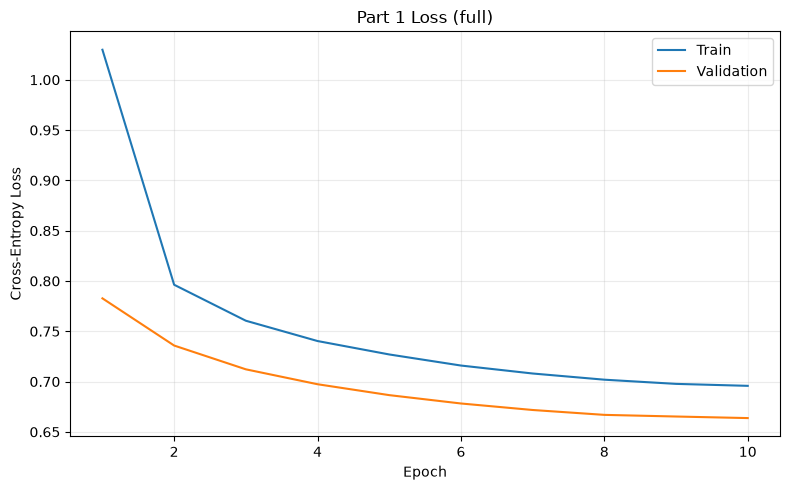

In [11]:
# Compact model checkpoint used for submission (full) or smoke verification (smoke).
final_checkpoint = {
    "model_state_dict": model.state_dict(),
    "config": CONFIG,
    "vocab": chars,
    "char_to_idx": char_to_idx,
    "idx_to_char": idx_to_char,
    "history": history,
}
torch.save(final_checkpoint, RUN_CKPT_DIR / "model.pt")
print("Saved:", RUN_CKPT_DIR / "model.pt")

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title(f"Part 1 Loss ({RUN_MODE})")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(RUN_OUTPUT_DIR / "loss_curve.png", dpi=160)
plt.show()

## 7. Generation metrics

In [12]:
def distinct_n(text, n):
    tokens = list(text)
    if len(tokens) < n:
        return 0.0
    ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
    return len(set(ngrams)) / max(1, len(ngrams))

def repeated_ngram_rate(text, n=4):
    tokens = list(text)
    if len(tokens) < n:
        return 0.0
    ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
    counts = Counter(ngrams)
    repeated_occurrences = sum(c for c in counts.values() if c > 1)
    return repeated_occurrences / max(1, len(ngrams))

prompts = ["Once upon a time", "The little girl", "One day"]
samples = []

gen_start = time.perf_counter()
generated_token_count = 0

for prompt in prompts:
    prompt_ids = encode(prompt).unsqueeze(0).to(DEVICE)
    out = model.generate(prompt_ids, max_new_tokens=400, temperature=0.8, greedy=False)
    generated_token_count += out.shape[1] - prompt_ids.shape[1]
    text = decode(out[0].cpu().tolist())
    samples.append({"prompt": prompt, "text": text})

gen_time = time.perf_counter() - gen_start
generation_tokens_per_sec = generated_token_count / max(gen_time, 1e-9)

with open(RUN_OUTPUT_DIR / "generated_samples.txt", "w", encoding="utf-8") as f:
    for i, s in enumerate(samples, 1):
        f.write(f"===== SAMPLE {i} =====\n{s['text']}\n\n")

(RUN_OUTPUT_DIR / "generated_samples.json").write_text(
    json.dumps(samples, indent=2, ensure_ascii=False), encoding="utf-8"
)

for i, s in enumerate(samples, 1):
    print(f"\n===== SAMPLE {i} =====")
    print(s["text"][:1200])


===== SAMPLE 1 =====
Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine, but one day she saw a big, shiny butterfly. Her name was Lily and her family. Lily was very excited, and Betsy laughed with joy.

Max said, "Wow, Lily, that's so cool! You're a very clever dog!" Lily was so excited and said, "It's really chores!" Lily wanted to know what it was, so she asked her mommy, "Can I please g

===== SAMPLE 2 =====
The little girl was so happy that she had made the story to her grandma happy too and thanked her for being so smart and brave.
Once upon a time, there was a boy named Timmy. Timmy loved to play outside with his favorite things. One day, Timmy's favorite toy car was coming. Timmy's mom was busy with the toy car and took it home. Timmy was very happy and he played with it every day at the park. They went outside 

===== SAMPLE 3 =====
One day, she found a new one that was pink and pretty. She thought it was fun to play with it because

## 8. Final metrics table

In [13]:
final_train_loss = float(history_df.iloc[-1]["train_loss"])
final_val_loss = float(history_df.iloc[-1]["val_loss"])
all_generated_text = "\n".join(s["text"] for s in samples)

current_peak_mb = torch.cuda.max_memory_allocated() / (1024**2) if torch.cuda.is_available() else 0.0
metrics = {
    "training_cross_entropy_loss": final_train_loss,
    "validation_cross_entropy_loss": final_val_loss,
    "perplexity": float(math.exp(min(final_val_loss, 20))),
    "bits_per_character": float(final_val_loss / math.log(2)),
    "generalization_gap": float(final_val_loss - final_train_loss),
    "top1_next_character_accuracy": float(history_df.iloc[-1]["val_top1_accuracy"]),
    "distinct_1": distinct_n(all_generated_text, 1),
    "distinct_2": distinct_n(all_generated_text, 2),
    "distinct_3": distinct_n(all_generated_text, 3),
    "repeated_4gram_rate": repeated_ngram_rate(all_generated_text, 4),
    "peak_gradient_norm": peak_grad_norm,
    "nan_count": nan_count,
    "parameter_count": PARAM_COUNT,
    "training_tokens_per_sec": float(history_df["train_tokens_per_sec"].mean()),
    "generation_tokens_per_sec": generation_tokens_per_sec,
    "peak_gpu_memory_mb": max(prior_peak_gpu_memory_mb, current_peak_mb),
    "total_training_time_seconds": total_train_time,
    "device": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
    "steps_per_epoch": STEPS_PER_EPOCH,
    "training_character_tokens": len(train_ids),
    "run_mode": RUN_MODE,
}
metrics_df = pd.DataFrame([metrics])
metrics_path = ARTIFACT_BASE / "metrics_report.csv"
metrics_df.to_csv(metrics_path, index=False)
print("Saved:", metrics_path)
metrics_df.T

Saved: /root/workspace/team-repo 6/task1_llm/kavya/Part1/metrics_report.csv


,0
training_cross_entropy_loss,0.695788
validation_cross_entropy_loss,0.663736
perplexity,1.942035
bits_per_character,0.957569
generalization_gap,-0.032051
top1_next_character_accuracy,0.787781
distinct_1,0.035484
distinct_2,0.221953
distinct_3,0.466074
repeated_4gram_rate,0.553759


## 9. Three generated-text failure cases

The notebook creates a starter file using three generated samples. **Read the actual text and replace
the failure labels/observations with your own analysis before submission.** The viva requires you to
explain these failures yourself.

In [17]:
# Create failure analysis from THIS run's generated samples.
ARTIFACT_BASE.mkdir(parents=True, exist_ok=True)

failure_types = [
    "Repetition and character inconsistency",
    "Grammar and logical inconsistency",
    "Character and scene inconsistency"
]

observations = [
    "The sample repeats the character name Lily several times and becomes inconsistent by calling Lily a girl first and then referring to her like a dog. The dialogue also becomes unnatural with phrases such as 'It's really chores!'",
    
    "The sample has awkward grammar and some events do not logically connect. For example, the toy car is described as 'coming,' and the sequence involving Timmy's mom and the toy car is unclear.",
    
    "The sample changes between Claire and Lily without explanation and the scene becomes inconsistent. It also includes confusing actions such as jumping into a rope and dialogue that does not clearly match the situation."
]

lines = ['# Part 1 Failure Analysis', '']

for i, sample in enumerate(samples[:3], 1):
    snippet = sample['text'][:900].strip()

    lines += [
        f'## Failure Case {i}',
        '**Generated snippet:**',
        snippet,
        '',
        f'**Failure type:** {failure_types[i-1]}',
        '',
        f'**Observation:** {observations[i-1]}',
        '',
        '---',
        ''
    ]

failure_template = '\n'.join(lines)

output_file = ARTIFACT_BASE / 'failure_analysis.md'
output_file.write_text(failure_template, encoding='utf-8')

print('Saved:', output_file)
print(failure_template)

Saved: /root/workspace/team-repo 6/task1_llm/kavya/Part1/failure_analysis.md
# Part 1 Failure Analysis

## Failure Case 1
**Generated snippet:**
Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine, but one day she saw a big, shiny butterfly. Her name was Lily and her family. Lily was very excited, and Betsy laughed with joy.

Max said, "Wow, Lily, that's so cool! You're a very clever dog!" Lily was so excited and said, "It's really chores!" Lily wanted to know what it was, so she asked her mommy, "Can I please g

**Failure type:** Repetition and character inconsistency

**Observation:** The sample repeats the character name Lily several times and becomes inconsistent by calling Lily a girl first and then referring to her like a dog. The dialogue also becomes unnatural with phrases such as 'It's really chores!'

---

## Failure Case 2
**Generated snippet:**
The little girl was so happy that she had made the story to her grandma happy too and t

## 10. Final artifact check

In [18]:
print('Files created under:', PART_DIR)
for p in sorted(PART_DIR.rglob('*')):
    if p.is_file():
        print(p.relative_to(PART_DIR))


Files created under: /root/workspace/team-repo 6/task1_llm/kavya/Part1
checkpoints/full/gpt_epoch_01.pt
checkpoints/full/gpt_epoch_02.pt
checkpoints/full/gpt_epoch_03.pt
checkpoints/full/gpt_epoch_04.pt
checkpoints/full/gpt_epoch_05.pt
checkpoints/full/gpt_epoch_06.pt
checkpoints/full/gpt_epoch_07.pt
checkpoints/full/gpt_epoch_08.pt
checkpoints/full/gpt_epoch_09.pt
checkpoints/full/gpt_epoch_10.pt
checkpoints/full/latest_checkpoint.pt
checkpoints/full/model.pt
config.json
failure_analysis.md
manifests/Kavya_task1_manifest.txt
metrics_report.csv
outputs/generated_samples.json
outputs/generated_samples.txt
outputs/loss_curve.png
raw_logs/Kavya_task1_full.log


In [19]:
# Create results.md from the actual run.
results_md = f'''# Part 1 Results

## Architecture
- Character-level GPT-style language model built from scratch
- Transformer blocks: {N_LAYERS}
- Hidden size: {D_MODEL}
- Attention heads: {N_HEADS}
- Context length: {BLOCK_SIZE}
- Dropout: {DROPOUT}
- Parameters: {PARAM_COUNT:,}

## Training
- Epochs: {EPOCHS}
- Batch size: {BATCH_SIZE}
- Steps per epoch: {STEPS_PER_EPOCH}
- Validation steps per epoch: {VAL_STEPS}
- Optimizer: AdamW
- Initial learning rate: {LEARNING_RATE}
- Warm-up steps: {WARMUP_STEPS}
- Device: {metrics['device']}
- Total training time (s): {metrics['total_training_time_seconds']:.2f}

## Final Metrics
- Training loss: {metrics['training_cross_entropy_loss']:.6f}
- Validation loss: {metrics['validation_cross_entropy_loss']:.6f}
- Perplexity: {metrics['perplexity']:.6f}
- Bits/character: {metrics['bits_per_character']:.6f}
- Generalization gap: {metrics['generalization_gap']:.6f}
- Top-1 next-character accuracy: {metrics['top1_next_character_accuracy']:.6f}
- Distinct-1: {metrics['distinct_1']:.6f}
- Distinct-2: {metrics['distinct_2']:.6f}
- Distinct-3: {metrics['distinct_3']:.6f}
- Repeated 4-gram rate: {metrics['repeated_4gram_rate']:.6f}
- Peak gradient norm: {metrics['peak_gradient_norm']:.6f}
- NaN count: {metrics['nan_count']}
- Training tokens/sec: {metrics['training_tokens_per_sec']:.2f}
- Generation tokens/sec: {metrics['generation_tokens_per_sec']:.2f}
- Peak GPU memory (MB): {metrics['peak_gpu_memory_mb']:.2f}

## Files
- Checkpoint: `checkpoints/{RUN_MODE}/model.pt`
- Metrics: `metrics_report.csv`
- Failure analysis: `failure_analysis.md`
- Outputs: `outputs/`
'''
(ARTIFACT_BASE / 'results.md').write_text(results_md, encoding='utf-8')
print(results_md)


# Part 1 Results

## Architecture
- Character-level GPT-style language model built from scratch
- Transformer blocks: 4
- Hidden size: 256
- Attention heads: 8
- Context length: 128
- Dropout: 0.1
- Parameters: 3,270,815

## Training
- Epochs: 10
- Batch size: 64
- Steps per epoch: 10936
- Validation steps per epoch: 1097
- Optimizer: AdamW
- Initial learning rate: 0.0003
- Warm-up steps: 500
- Device: NVIDIA GeForce RTX 4090
- Total training time (s): 3911.65

## Final Metrics
- Training loss: 0.695788
- Validation loss: 0.663736
- Perplexity: 1.942035
- Bits/character: 0.957569
- Generalization gap: -0.032051
- Top-1 next-character accuracy: 0.787781
- Distinct-1: 0.035484
- Distinct-2: 0.221953
- Distinct-3: 0.466074
- Repeated 4-gram rate: 0.553759
- Peak gradient norm: 7.064823
- NaN count: 0
- Training tokens/sec: 243356.89
- Generation tokens/sec: 467.92
- Peak GPU memory (MB): 940.81

## Files
- Checkpoint: `checkpoints/full/model.pt`
- Metrics: `metrics_report.csv`
- Failure a

In [20]:

# Save environment/package manifest for reproducibility.
import subprocess
manifest_path = MANIFEST_DIR / f"{MEMBER_NAME}_task1_manifest.txt"

with open(manifest_path, "w", encoding="utf-8") as f:
    f.write(f"Python: {platform.python_version()}\n")
    f.write(f"PyTorch: {torch.__version__}\n")
    f.write(f"Device: {DEVICE}\n")
    if torch.cuda.is_available():
        f.write(f"GPU: {torch.cuda.get_device_name(0)}\n")
    f.write("\n--- pip freeze ---\n")
    try:
        freeze = subprocess.check_output(
            [sys.executable, "-m", "pip", "freeze"], text=True
        )
        f.write(freeze)
    except Exception as e:
        f.write(f"Could not capture pip freeze: {e}\n")

print("Saved manifest:", manifest_path)


Saved manifest: /root/workspace/team-repo 6/task1_llm/kavya/Part1/manifests/Kavya_task1_manifest.txt
